In [1]:
# Importing Libraries 
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

In [2]:
# Importing the dataset
users = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Users")
teachers = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Teachers")
courses = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Courses")
transactions = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Transactions")

In [3]:
# Users first 5 columns 
users.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [4]:
# Teachers first 5 columns
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [5]:
# Courses first 5 columns 
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [6]:
# transactions first 5 rows
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [7]:
# Checking the column names of the datasets
print("\nColumns of Users\n",users.columns)
print("\nColumns of Teachers\n",teachers.columns)
print("\nColumns of Courses\n",courses.columns)
print("\nColumns of Transaction\n",transactions.columns)


Columns of Users
 Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

Columns of Teachers
 Index(['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='object')

Columns of Courses
 Index(['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating'],
      dtype='object')

Columns of Transaction
 Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='object')


In [8]:
# Merging all tables
df = transactions.merge(users, on="UserID")
df = df.merge(courses, on="CourseID")
df = df.merge(teachers, on="TeacherID")

In [9]:
# Checking the merged dataset
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age_x,Gender_x,...,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Age_y,Gender_y,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,Intermediate,0.0,42.68,4.72,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,Intermediate,0.0,33.93,3.45,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,...,Advanced,0.0,18.00,2.98,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,...,Beginner,0.0,42.70,3.64,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,...,Beginner,0.0,8.95,2.14,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [10]:
# Checking the columns of the datset 
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age_x', 'Gender_x', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherName', 'Age_y',
       'Gender_y', 'Expertise', 'YearsOfExperience', 'TeacherRating'],
      dtype='object')

In [11]:
# Renaming the required columns 
df.rename(columns={"Age_x":"UserAge", "Gender_x": "UserGender", "Age_y": "TeacherAge", "Gender_y":"TeacherGender"},inplace=True)

In [12]:
# Checking the columns again 
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'UserAge', 'UserGender',
       'Email', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherName',
       'TeacherAge', 'TeacherGender', 'Expertise', 'YearsOfExperience',
       'TeacherRating'],
      dtype='object')

In [13]:
# Dropping the unnecessary Columns 
df.drop(columns=["TransactionID", "Email", "TeacherAge", "TeacherGender"], inplace=True)

In [14]:
# Checking the dataset again
df.head()

,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,UserAge,UserGender,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Expertise,YearsOfExperience,TeacherRating
0,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,Kimberly Miller,Cybersecurity,24,4.58
1,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,Kimberly Miller,Cybersecurity,24,4.58
2,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,Kimberly Miller,Cybersecurity,24,4.58
3,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,Kimberly Miller,Cybersecurity,24,4.58
4,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,Yolanda Levine,Machine Learning,21,4.97


In [15]:
# Checking for null values 
df.isnull().sum()

UserID               0
CourseID             0
TransactionDate      0
Amount               0
PaymentMethod        0
TeacherID            0
UserName             0
UserAge              0
UserGender           0
CourseName           0
CourseCategory       0
CourseType           0
CourseLevel          0
CoursePrice          0
CourseDuration       0
CourseRating         0
TeacherName          0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

In [16]:
# Checking information of the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   UserID             10000 non-null  object        
 1   CourseID           10000 non-null  object        
 2   TransactionDate    10000 non-null  datetime64[ns]
 3   Amount             10000 non-null  float64       
 4   PaymentMethod      10000 non-null  object        
 5   TeacherID          10000 non-null  object        
 6   UserName           10000 non-null  object        
 7   UserAge            10000 non-null  int64         
 8   UserGender         10000 non-null  object        
 9   CourseName         10000 non-null  object        
 10  CourseCategory     10000 non-null  object        
 11  CourseType         10000 non-null  object        
 12  CourseLevel        10000 non-null  object        
 13  CoursePrice        10000 non-null  float64       
 14  CourseD

In [17]:
# Deriving the statistical matrix of the dataset 
df.describe()

,TransactionDate,Amount,UserAge,CoursePrice,CourseDuration,CourseRating,YearsOfExperience,TeacherRating
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347,24.965700,91.132347,27.509536,3.123277,16.024100,4.087769
min,2025-01-01 00:00:00,0.000000,15.000000,0.000000,1.200000,1.130000,1.000000,1.050000
25%,2025-04-02 00:00:00,0.000000,20.000000,0.000000,12.130000,2.140000,7.000000,3.460000
50%,2025-06-30 00:00:00,0.000000,25.000000,0.000000,28.330000,3.110000,21.000000,4.580000
75%,2025-09-28 00:00:00,119.040000,30.000000,119.040000,42.700000,4.110000,24.000000,4.970000
max,2025-12-30 00:00:00,490.900000,35.000000,490.900000,49.730000,4.940000,24.000000,4.970000
std,NaN,152.063524,6.051858,152.063524,16.011616,1.156254,8.521783,1.069542


In [18]:
# Checking for unique values 
df.nunique()

UserID               3000
CourseID               60
TransactionDate       358
Amount                 23
PaymentMethod           3
TeacherID              60
UserName             3000
UserAge                21
UserGender              2
CourseName             58
CourseCategory         12
CourseType              2
CourseLevel             3
CoursePrice            23
CourseDuration         60
CourseRating           56
TeacherName            60
Expertise              12
YearsOfExperience      16
TeacherRating          56
dtype: int64

In [19]:
# Checking unique categorical value 
df['CourseCategory'].unique()

array(['Marketing', 'Project Management', 'Artificial Intelligence',
       'Digital Marketing', 'Finance', 'Data Science', 'Programming',
       'Cybersecurity', 'Machine Learning', 'Design', 'Business',
       'Web Development'], dtype=object)

In [20]:
df['CourseLevel'].unique()

array(['Intermediate', 'Advanced', 'Beginner'], dtype=object)

In [21]:
df['PaymentMethod'].unique()

array(['PayPal', 'Bank Transfer', 'Credit Card'], dtype=object)

In [22]:
# Values of each Category
df['CourseCategory'].value_counts()

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Artificial Intelligence    829
Project Management         829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Marketing                  806
Programming                806
Name: count, dtype: int64

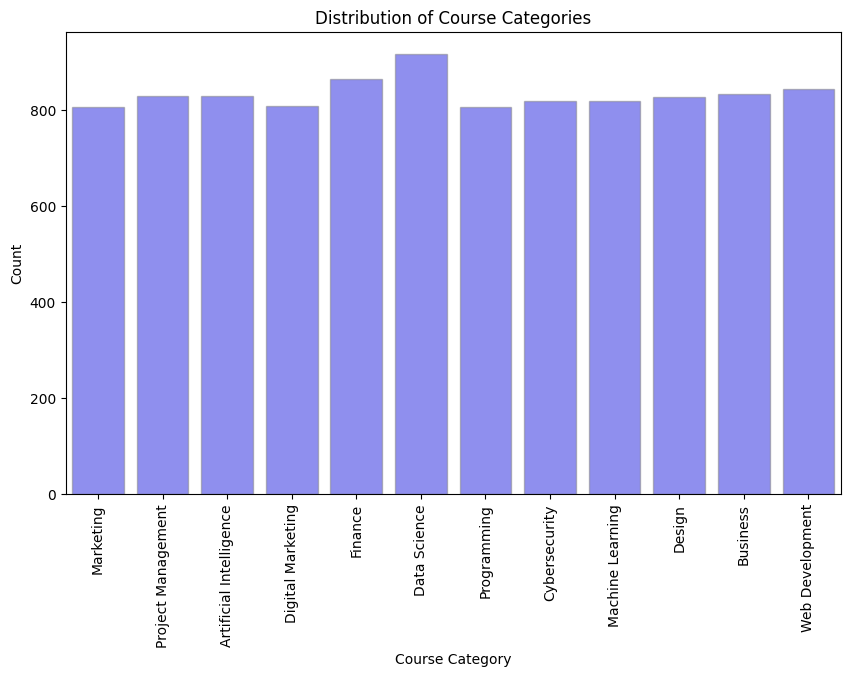

In [23]:
# Course Category Distribution 
plt.figure(figsize=(10,6))
sns.countplot(x='CourseCategory', data=df, color='blue',edgecolor='gray', alpha=0.5)
plt.xticks(rotation=90)
plt.xlabel('Course Category')
plt.ylabel('Count')
plt.title('Distribution of Course Categories')
plt.show()

#### Insights
- Data Science has the highest no of courses (~920) this shows very high demand for data related skills, also indicates learners are strongly intrested in Analytics, AI and Machine Learning careers.

- Followed by AI, ML, Programing , Cybersecurity, Web Development with course counts ranging from (820-850).

- Management and business related courses follow with moderately high counts, including Marketing, Digital Marketing, Project Management, Business, and Finance.

- All categories range roughly between 800 to 920.

- Emerging career-oriented skill areas include Artificial Intelligence, Machine Learning, Cybersecurity, and Data Science.

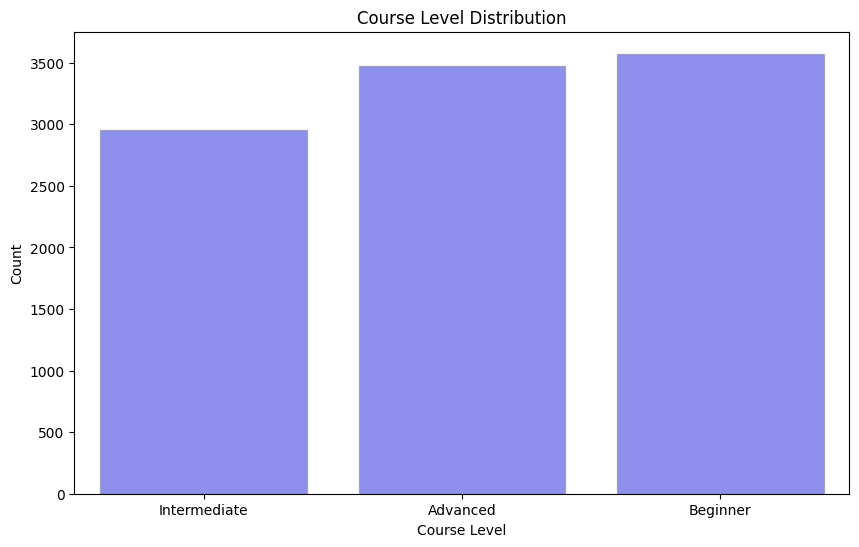

In [24]:
# Course Level Distribution 
plt.figure(figsize=(10,6))
sns.countplot(x='CourseLevel', data=df, color='blue', edgecolor='gray', alpha=0.5)
plt.title('Course Level Distribution')
plt.xlabel('Course Level')
plt.ylabel('Count')
plt.show()

#### Insights

- Beginner level course have the highest count (~3600). This indicates that the platform focuses on attracting new learners who are starting their learning journey and building fondational skills.

- Advanced level courses follow with around (~3500) courses. This shows that the platform also supports experienced learners who want to deepen their expertise and specialize in advanced topics.

- Intermediate level courses have the lowest count (~2950). Although slightly lower than other course it still represents significant portion of the courses offered.

- The distribution across Beginner, Intermediate and Advanced levels is relativly balanced. This suggests that the platform provides learning oppurtunities for users at all skill levels, from beginners to advanced levels professionals.

- The higher number of beginner courses may indicate that the platform prioritizes accessibility and onboarding new learners, helping them enter technical and professional domains before progressing to higher levels.

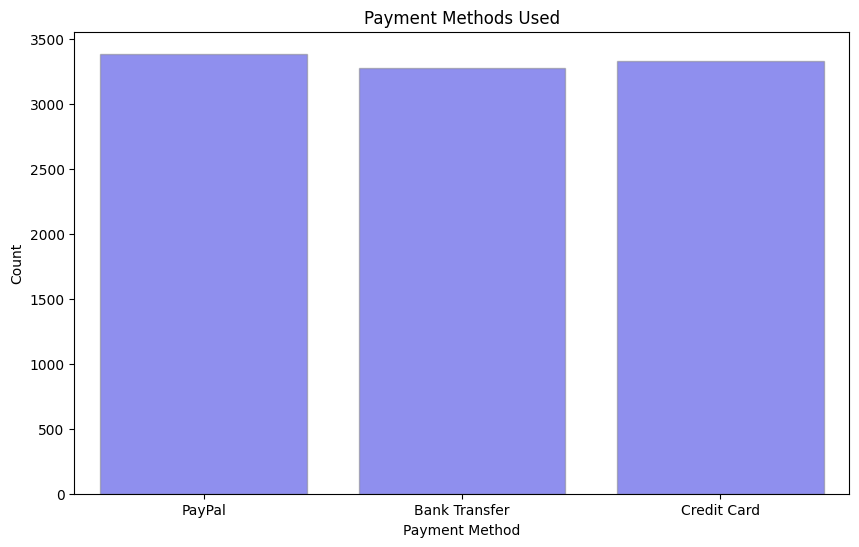

In [25]:
# Payment methods used
plt.figure(figsize=(10,6))
sns.countplot(x="PaymentMethod", data=df, color='blue', edgecolor='gray', alpha=0.5)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title("Payment Methods Used")
plt.show()

### Insights

- PayPal has the highest usage (~3400). This indicates that users prefer fast, secure and global accepted digital payment methods.

- Credit card usage is slightly lower (~ 3350). This shows that traditional online payment methods are still widely used and trusted by users.

- Bank transfer has the lowest count (~3250). This suggests that user may find it slower or less convenient compared to instant payment methods.

- The diffrence between all payment method is relativly small. This indicates a balanced prefrence among users, with no single method dominating completely.

- Overall, users tend to prefer quick and convenient digital payment options (PayPal and Credit Cards) over more manual methods like bank transfers.


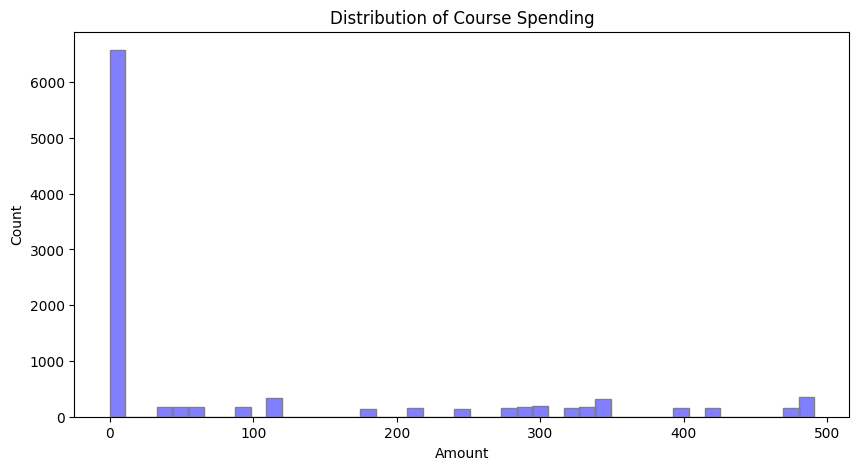

In [26]:
# Distribution of course spending 
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], color='blue',edgecolor='gray', alpha=0.5)
plt.xlabel('Amount')
plt.ylabel('Count')
plt.title("Distribution of Course Spending")
plt.show()

### Insights
- A very large number of users have spending close to 0. This indicates that many users are either not purchasing courses or are only engaging with free content on the platform.

- The distribution is highly right-skewed. Most users spend very little, while a small number of users spend higher amounts (100–500 range).

- There are a few high-spending users. These users contribute significantly to revenue, indicating the presence of premium or highly engaged customers.

- Spending values are spread across a wide range (0 to 500). This shows that the platform caters to different types of users, from free learners to premium buyers.

- Majority of revenue likely comes from a small group of users. This suggests a typical Pareto (80/20) pattern, where a small percentage of users generate most of the income.

- **Opportunity Insight:** The platform can focus on converting free users into paying customers through offers, discounts, or premium content strategies.

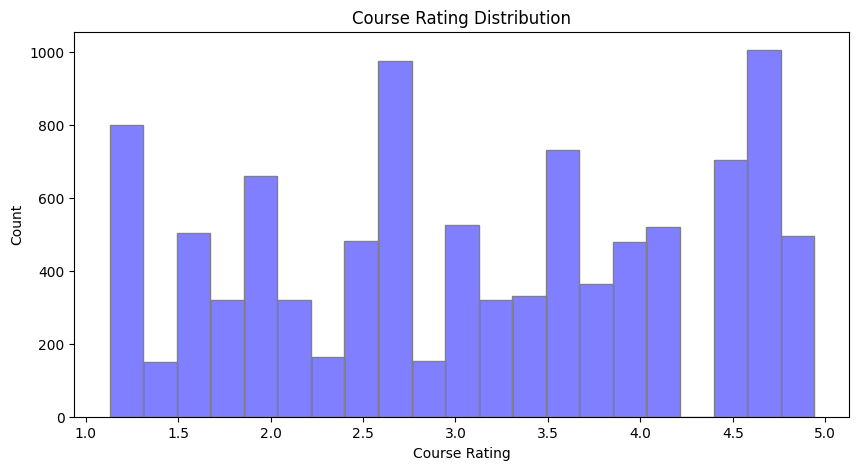

In [27]:
# Course Rating Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['CourseRating'], color = 'blue' , edgecolor='gray', alpha = 0.5)
plt.title("Course Rating Distribution")
plt.xlabel('Course Rating')
plt.ylabel('Count')
plt.show()

### Insights 

- Most course ratings are concentrated between 3.5 and 5.0. This indicates that the majority of courses are well-received by learners and maintain good quality.

- A significant number of courses have ratings above 4.0. This suggests high user satisfaction and positive learning experiences across the platform.

- There are fewer courses with low ratings (below 2.5). This shows that only a small portion of courses may have quality or content issues.

- The distribution is slightly left-skewed (towards higher ratings). This means users generally tend to give positive feedback rather than negative ratings.

- Ratings are spread across the full range (1 to 5). This indicates that while most courses perform well, there is still variation in course quality.

- **Insight for improvement:** The platform can analyze low-rated courses to identify gaps and improve content quality, while also promoting high-rated courses to attract more learners.

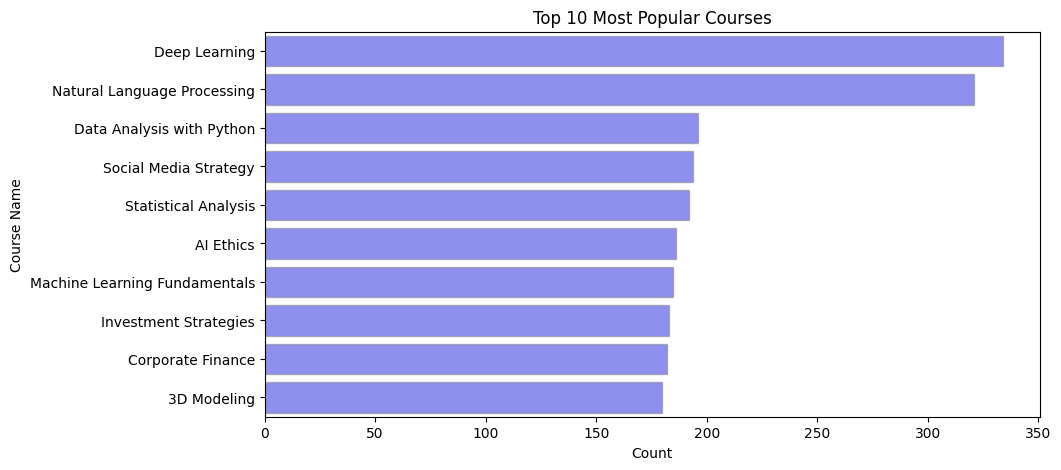

In [28]:
# Top 10 Most Popular Courses
top_courses = df['CourseName'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_courses.values, y=top_courses.index, color= 'blue', edgecolor = 'gray', alpha=0.5)
plt.xlabel('Count')
plt.ylabel('Course Name')
plt.title("Top 10 Most Popular Courses")
plt.show()

### Insights 

- Deep learning is the most popular course (~ 335 enrollments). This shows a very high intrest in advanced AI topics among learners.

- Natural language processing follows closely (~320 enrollments). This indicates strong demand for AI applications related to text, chatbots and language models.

- Data analysis with python ranks third (~195 enrollments). This highlights the importance of practical data skills and programming in real world aplications.

- Courses like social media strategy and statistical analysis also hav3 high popularity (~190 - 195). This shows a mix of intrest in both technical and business oriented skills.

- AI related course dominate the top rankings. Courses such as Deep learning, NLP and Machine learning fundamentals and AI Ethics reflect a strong trend toward AI driven careers.

- Finance and business courses like investment strateges and corporate finance are also present. This indicates that learners are focused on financial knowledge and decision making skills.

- This diffrence in enrollments between mid ranked courses is small. This suggests a fairly even intrest across multiple domains, not just a single field.

- **Overall Insight -** Learners are highly incliend towards AI, data science and technology based courses, while still maintaining intrest in business and creative fields like 3D Modeling and Social Media Strategy.

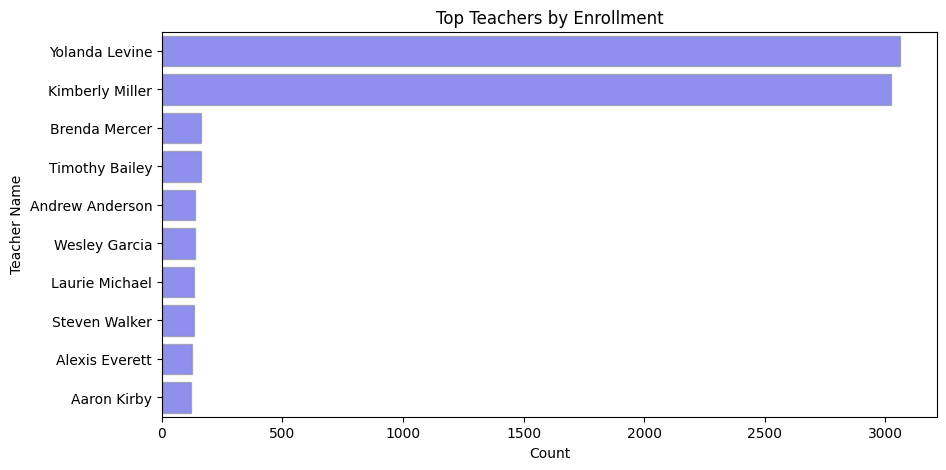

In [29]:
# Top teachers by enrollment 
top_teachers = df['TeacherName'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_teachers.values, y=top_teachers.index, color='blue', edgecolor='gray', alpha=0.5)
plt.title("Top Teachers by Enrollment")
plt.xlabel('Count')
plt.ylabel('Teacher Name')
plt.show()

### Insights
- Yolanda Levine has the highest enrollments (~3100). This indicates she is the most popular instructor, likely due to high-quality content or highly demanded courses.

- Kimberly Miller follows closely (~3050 enrollments). This shows that she is also a top performing instructor with strong learner engagement.

- There is a huge gap between the top 2 instructors and others. The remaining teachers have enrollments below (~200), indicating a significant difference in popularity.

- Most instructors have relatively low enrollments. This suggests that only a few instructors are driving the majority of student engagement on the platform.

- Enrollment distribution is highly skewed. A small number of instructors (top 2) contribute to a large portion of total enrollments.

- Possible reason: Top instructors may be teaching high demand subjects like AI, Data Science, or Programming which attract more learners.

- **Insight for platform:** The platform can analyze what makes top instructors successful (content quality, teaching style, topics) and apply those strategies to improve performance of other instructors.

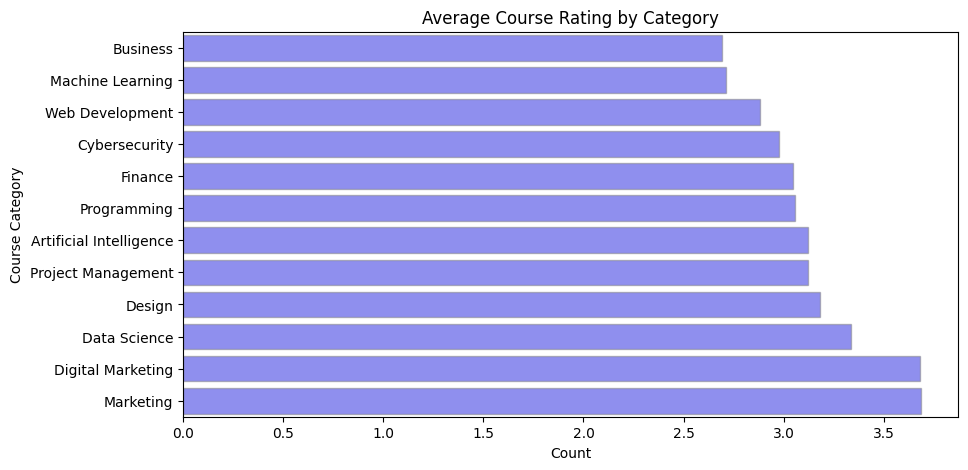

In [30]:
# Average Course rating by category
category_rating = df.groupby('CourseCategory')['CourseRating'].mean().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=category_rating.values, y=category_rating.index, color='blue', edgecolor= 'gray', alpha=0.5)
plt.title("Average Course Rating by Category")
plt.xlabel('Count')
plt.ylabel('Course Category')
plt.show()

### Insights 
- Marketing and Digital Marketing have the highest average ratings (~3.7). This indicates that learners are highly satisfied with marketing related courses, possibly due to practical and easy to understand content.

- Data Science follows with a strong average rating (~3.5). This shows that despite being a complex field, courses are well structured and appreciated by learners.

- Design, Project Management, and Artificial Intelligence have ratings around (~3.2–3.3). This suggests consistent quality and good learner satisfaction across these domains.

- Programming, Finance, and Cybersecurity have slightly lower but stable ratings (~3.0–3.1). This indicates that these courses are reliable but may have scope for improvement.

- Web Development and Machine Learning have ratings around (~2.8–3.0). This could suggest that some courses in these categories may be challenging or need better content delivery.

- Business has the lowest average rating (~2.7). This indicates comparatively lower learner satisfaction, possibly due to less engaging or more theoretical content.

- **Overall Insight:** Most categories have ratings above 3.0, indicating generally good course quality across the platform, with marketing related domains performing the best.

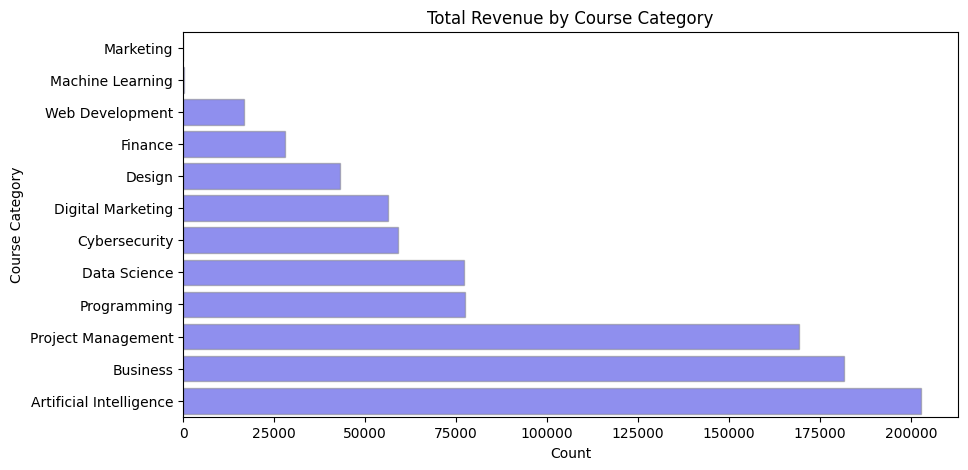

In [31]:
# Total Revenue by Course Category
category_spend = df.groupby('CourseCategory')['Amount'].sum().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=category_spend.values, y=category_spend.index, color='blue', edgecolor='gray', alpha=0.5)
plt.title("Total Revenue by Course Category")
plt.xlabel('Count')
plt.ylabel('Course Category')
plt.show()

### Insights
- Artificial Intelligence generates the highest revenue (~205K). This shows that AI courses are not only popular but also highly profitable, indicating strong market demand.

- Business (~180K) and Project Management (~170K) follow next. This suggests that professional and corporate skill based courses contribute significantly to overall revenue.

- Programming and Data Science generate moderate revenue (~80K each). Despite high popularity, their revenue is comparatively lower, possibly due to lower pricing or more free/discounted courses.

- Cybersecurity and Digital Marketing have mid level revenue (~60K). This indicates steady demand and consistent learner interest in these domains.

- Design (~45K) and Finance (~30K) contribute moderate to low revenue. These categories may have niche audiences or fewer premium courses.

- Web Development (~20K) has relatively lower revenue. This could be due to high competition or availability of free resources online.

- Marketing and Machine Learning show minimal revenue contribution. This suggests either lower enrollments, pricing issues, or fewer available courses in these categories.

- Overall Insight: Revenue is not evenly distributed across categories, with a few domains like AI, Business, and Project Management driving the majority of earnings, highlighting key areas for platform growth and investment.

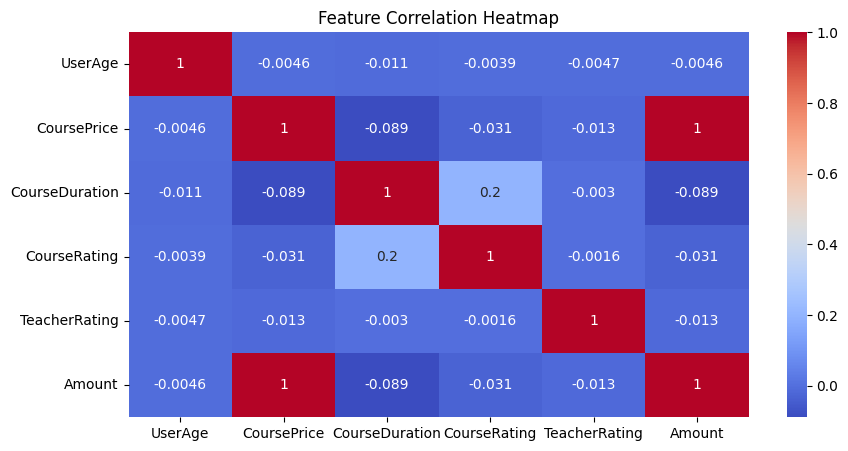

In [32]:
# Feature Correlation Map 
plt.figure(figsize=(10,5))
sns.heatmap(df[['UserAge','CoursePrice','CourseDuration','CourseRating','TeacherRating','Amount']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Insights
- Course Price and Amount show a perfect positive correlation (1.0). This indicates that the total amount spent is directly dependent on the course price, which is expected.

- Course Duration and Course Rating have a slight positive correlation (~0.2).** This suggests that longer courses may slightly lead to better ratings, possibly due to more detailed content.

- Most other features show very weak or near-zero correlations. This means variables like User Age, Teacher Rating, and Course Rating are largely independent of each other.

- User Age has almost no correlation with any feature.** This indicates that learners of all age groups behave similarly in terms of spending, ratings, and course selection.

- Teacher Rating has negligible correlation with Course Rating and Amount. This suggests that teacher ratings may not strongly influence course ratings or spending behavior.

- Course Price has a slight negative correlation with Course Duration and Rating. This could indicate that higher-priced courses are not necessarily longer or better rated.

- **Overall Insight:** The dataset shows low inter-feature dependency, meaning most variables operate independently, except for the strong relationship between price and total spending.


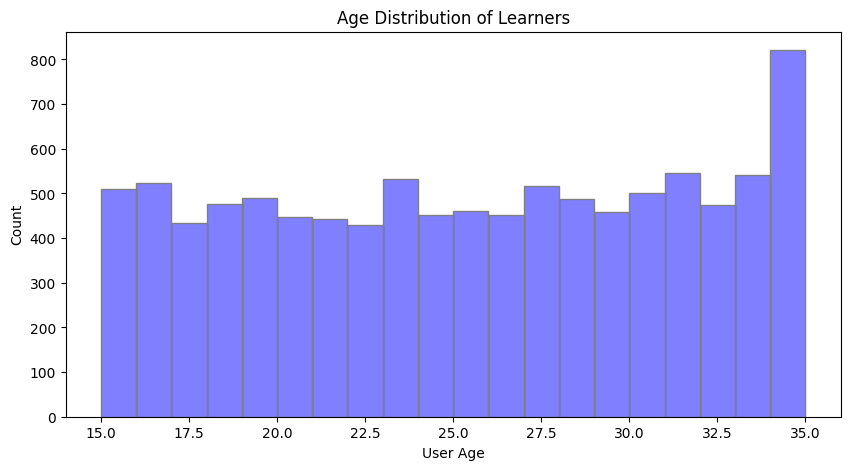

In [33]:
# Age distribution of learners 
plt.figure(figsize=(10,5))
sns.histplot(df['UserAge'], bins=20, color = 'blue',edgecolor = 'gray', alpha = 0.5)
plt.title("Age Distribution of Learners")
plt.xlabel('User Age')
plt.ylabel('Count')
plt.show()

### Insights

- Learner age is distributed between 15 and 35 years. This shows that the platform mainly attracts young learners and early professionals.

- The distribution is fairly uniform across all age groups. This indicates that there is no strong concentration in a specific age range, and learners from different age groups are actively using the platform.

- Slightly higher counts are observed in the 30–35 age group. This suggests that working professionals are also highly engaged in upskilling and continuous learning.

- Younger learners (15–25) also form a significant portion. This indicates strong interest from students and beginners starting their careers.

- No extreme peaks or drops in age distribution. This shows a balanced user base across different age segments.

- **Overall Insight:** The platform successfully caters to a wide age range, from students to professionals, making it suitable for both learning and career advancement.

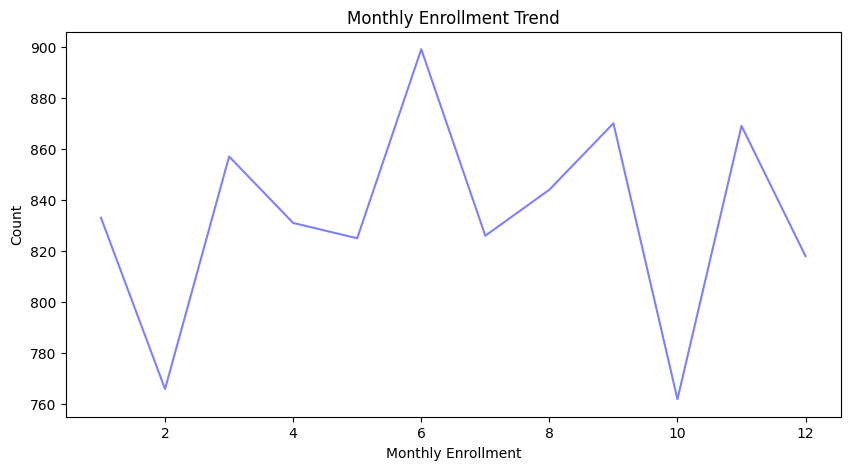

In [34]:
# Monthly Enrollment Trend 
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
monthly_enrollment = df.groupby('Month')['CourseID'].count()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_enrollment.index, y=monthly_enrollment.values,color='blue',alpha=0.5)
plt.title("Monthly Enrollment Trend")
plt.xlabel('Monthly Enrollment')
plt.ylabel('Count')
plt.show()

### Insights
- Enrollments show noticeable fluctuations across months. This indicates that user activity is not consistent throughout the year and varies over time.

- The highest enrollment is observed around Month 6 (~900). This suggests a peak learning period, possibly due to mid-year motivation, academic cycles, or promotional offers.

- Lower enrollments are seen in Month 2 and Month 10 (~760–770). This indicates temporary drops in user engagement, which could be due to exams, holidays, or reduced platform activity.

- There is a recovery trend after low points. For example, after the drop in Month 2, enrollments increase again in Month 3, and similarly after Month 10, there is a rise in Month 11.

- Moderate stability is observed between Months 3 to 9. During this period, enrollments remain relatively steady with small variations, indicating consistent user engagement.

- No clear long-term upward or downward trend. This suggests that enrollments are seasonal or event-driven rather than steadily growing or declining.

- Overall Insight: The platform experiences seasonal fluctuations in enrollments, with certain peak months driving higher engagement. This highlights opportunities for targeted marketing campaigns during low activity periods to maintain consistent growth.

In [35]:
# Creating learner level features 

In [36]:
# Total Courses Enrolled 
total_courses = df.groupby('UserID')['CourseID'].count()
total_courses.head()

UserID
U00001     1
U00002     1
U00003    11
U00004    13
U00005     2
Name: CourseID, dtype: int64

In [37]:
# Average Spending 
avg_spend = df.groupby('UserID')['Amount'].mean()
avg_spend.head()

UserID
U00001    394.260000
U00002      0.000000
U00003     55.816364
U00004     75.542308
U00005    173.355000
Name: Amount, dtype: float64

In [38]:
# Diversity Score 
# (Low meaning Specialist and High meaning explorer)
diversity = df.groupby('UserID')['CourseCategory'].nunique()
diversity.head()

UserID
U00001    1
U00002    1
U00003    7
U00004    8
U00005    2
Name: CourseCategory, dtype: int64

In [39]:
# Average course rating taken
avg_rating = df.groupby('UserID')['CourseRating'].mean()
avg_rating.head()

UserID
U00001    1.350000
U00002    2.880000
U00003    2.889091
U00004    3.451538
U00005    2.055000
Name: CourseRating, dtype: float64

In [40]:
# Average course duration 
avg_duration = df.groupby('UserID')['CourseDuration'].mean()
avg_duration.head()

UserID
U00001    47.440
U00002    45.130
U00003    22.730
U00004    24.130
U00005    24.275
Name: CourseDuration, dtype: float64

In [41]:
# Learning Depth index 
advanced = df[df['CourseLevel'] == 'Advanced']
depth = advanced.groupby('UserID')['CourseID'].count()
depth.head()

UserID
U00003    4
U00004    3
U00005    1
U00006    1
U00009    1
Name: CourseID, dtype: int64

In [42]:
# Create learner profile dataset 
learner_profile = pd.DataFrame({
    'TotalCourses': total_courses,
    'AvgSpend' : avg_spend,
    'DiversityScore' : diversity,
    'AvgRating' : avg_rating,
    'AvgDuration' : avg_duration,
    'AdvancedCourses' : depth
})

learner_profile.reset_index(inplace=True)

In [43]:
learner_profile.head()

,UserID,TotalCourses,AvgSpend,DiversityScore,AvgRating,AvgDuration,AdvancedCourses
0,U00001,1,394.260000,1,1.350000,47.440,NaN
1,U00002,1,0.000000,1,2.880000,45.130,NaN
2,U00003,11,55.816364,7,2.889091,22.730,4.0
3,U00004,13,75.542308,8,3.451538,24.130,3.0
4,U00005,2,173.355000,2,2.055000,24.275,1.0


In [44]:
# Adding demographics 
demographics = df[['UserID', 'UserAge', 'UserGender']].drop_duplicates()
learner_profile=learner_profile.merge(demographics,on='UserID')

In [45]:
learner_profile.head()

,UserID,TotalCourses,AvgSpend,DiversityScore,AvgRating,AvgDuration,AdvancedCourses,UserAge,UserGender
0,U00001,1,394.260000,1,1.350000,47.440,NaN,15,Male
1,U00002,1,0.000000,1,2.880000,45.130,NaN,29,Female
2,U00003,11,55.816364,7,2.889091,22.730,4.0,33,Female
3,U00004,13,75.542308,8,3.451538,24.130,3.0,23,Female
4,U00005,2,173.355000,2,2.055000,24.275,1.0,21,Male


In [46]:
# Encoding gender 
learner_profile['UserGender'] = learner_profile['UserGender'].map({
    'Male':0,
    'Female':1
})

In [47]:
# Selecting features for clustering 
features = learner_profile[
    ['UserAge','UserGender','TotalCourses','AvgSpend',
     'DiversityScore','AvgRating','AvgDuration','AdvancedCourses']
]

In [49]:
# Checking for null values
pd.DataFrame(features).isnull().sum()

UserAge               0
UserGender            0
TotalCourses          0
AvgSpend              0
DiversityScore        0
AvgRating             0
AvgDuration           0
AdvancedCourses    1392
dtype: int64

In [50]:
# Handle NaN Values 
imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

In [51]:
# Checking for null values again 
pd.DataFrame(features_imputed).isnull().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

In [52]:
# Scaling the data 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_imputed)

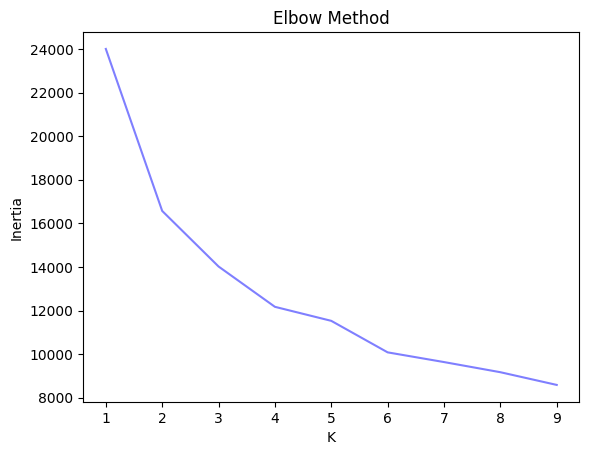

In [53]:
# Find Optimal Clusters (Elbow Method)
inertia =[]
for k in range(1,10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia.append(model.inertia_)
plt.plot(range(1,10), inertia, color='blue', alpha=0.5)
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

### Interpretation
The Elbow Method graph shows a sharp decrease in inertia from K = 1 to K = 4, after which the rate of decrease slows down significantly. This indicates that adding more clusters beyond K = 4 does not provide substantial improvement. Therefore, the optimal number of clusters is 4.

In [55]:
# Apple KMeans 
kmeans=KMeans(n_clusters=4, random_state=42)
learner_profile['Cluster'] = kmeans.fit_predict(features_imputed)

In [56]:
# Check Cluster Summary
learner_profile.groupby('Cluster').mean(numeric_only=True)

,TotalCourses,AvgSpend,DiversityScore,AvgRating,AvgDuration,AdvancedCourses,UserAge,UserGender
Cluster,,,,,,,,
0,7.704852,118.958231,5.384097,3.053124,28.396239,3.293729,24.878706,0.521563
1,1.078571,450.606679,1.064286,3.497500,26.386214,1.000000,24.028571,0.457143
2,2.047973,7.296813,1.751571,3.207436,28.159392,1.554612,25.088521,0.505425
3,1.487738,283.123640,1.419619,2.804156,23.934579,1.141844,24.983651,0.501362


### Cluster Labels 
* 1 -> Casual Learners 
* 2 -> Explorers 
* 3 -> Speacialists
* 4 -> Carrer Focused 

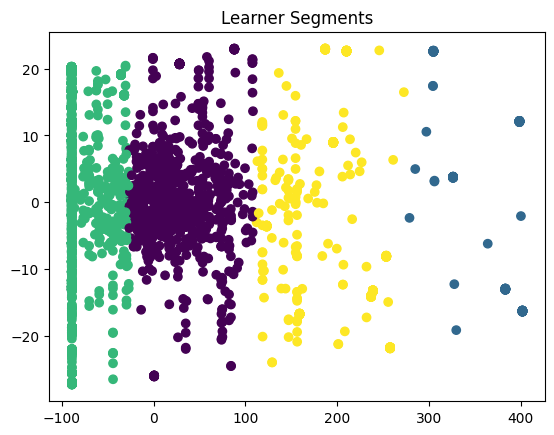

In [57]:
# Visualizing Clusters
pca = PCA(n_components=2)
pca_data = pca.fit_transform(features_imputed)

plt.scatter(pca_data[:,0], pca_data[:, 1], c=learner_profile['Cluster'])
plt.title("Learner Segments")
plt.show()

### Interpretation 
1. Cluster 0 (Low Engagement Users)
    - Low spending
    - Fewer courses
    - Low activity
      
**These are mostly new or inactive users** 

2. Cluster 1 (Moderate Users)
   - Middle spending 
   - Average number of courses
   - Regular activity

**These are consistent learners who engage regularly but are not heavy spenders**

3. Cluster 2 (High Value Users)
    - Very high spending
    - High course consumption
    - Possibly advanced learners

**These users generate maximum revenue -> most valuable segment**

4. Cluster 3 (Premium / Power Users)
    - Very high spending
    - High course consumption
    - Possibly advanced learners

**These users generate maximum revenue -> most valuable segment**

In [58]:
# Cluster based recommendation

In [59]:
# Merging cluster information
cluster_data = df.merge(learner_profile[['UserID','Cluster']],on='UserID')
cluster_data.head()

,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,UserAge,UserGender,CourseName,...,CoursePrice,CourseDuration,CourseRating,TeacherName,Expertise,YearsOfExperience,TeacherRating,Year,Month,Cluster
0,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,Digital Marketing,...,0.0,42.68,4.72,Kimberly Miller,Cybersecurity,24,4.58,2025,10,2
1,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,Scrum Essentials,...,0.0,33.93,3.45,Kimberly Miller,Cybersecurity,24,4.58,2025,1,2
2,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,Content Marketing,...,0.0,18.00,2.98,Kimberly Miller,Cybersecurity,24,4.58,2025,3,2
3,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,AI Ethics,...,0.0,42.70,3.64,Kimberly Miller,Cybersecurity,24,4.58,2025,6,0
4,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,Content Creation,...,0.0,8.95,2.14,Yolanda Levine,Machine Learning,21,4.97,2025,8,0


In [60]:
# Find popular courses per cluster
popular_courses = cluster_data.groupby(['Cluster', 'CourseName']).size().reset_index(name='Enrollments')
popular_courses = popular_courses.sort_values(['Cluster','Enrollments'],ascending=False)

In [61]:
# Recommendation function
def recommend_function(user_id):
    user_data = learner_profile[learner_profile['UserID'] == user_id]
    if user_data.empty:
        return "User not found"
    cluster = user_data['Cluster'].values[0]
    rec = popular_courses[popular_courses['Cluster'] == cluster].head(5)
    return rec

In [62]:
recommend_function('U00003')

,Cluster,CourseName,Enrollments
108,2,Natural Language Processing,119
69,2,3D Modeling,93
102,2,Investment Strategies,93
123,2,Social Media Strategy,91
70,2,AI Ethics,90


In [63]:
# Content based filtering 

In [64]:
# Create User Prefrence Profile
user_pref = df.groupby(['UserID', 'CourseCategory']).size().reset_index(name='count')
user_pref =user_pref.sort_values(['UserID', 'count'], ascending=False)
user_pref = user_pref.drop_duplicates('UserID')

In [65]:
# Recommendation logic 
def recommend_content(user_id):
    pref = user_pref[user_pref['UserID']==user_id]['CourseCategory'].values[0]
    rec = df[df['CourseCategory']==pref]['CourseName'].value_counts().head(5)
    return rec

In [66]:
# Hybrid Recommendation 
def hybrid_reccmmend(user_id):
    cluster_rec = recommend_content(user_id)['CourseName'].tolist()
    content_rec = recommend_content(user_id).index.tolist()
    final = list(set(cluster_rec+content_rec))
    return final[:5]

In [67]:
# Avoiding already taken courses
def hybrid_recommend_v2(user_id):
    taken = df[df['UserID']==user_id]['CourseName'].tolist()
    recs = hybrid_recommend(user_id)
    final = [course for course in recs if course not in taken]
    return final[:5]

In [68]:
# Adding ranking 
course_score = df.groupby('CourseName').agg({
    'CourseRating':'mean',
    'UserID':'count'
}).rename(columns={'UserID':'Popularity'})

course_score['Score']=course_score['CourseRating']* course_score['Popularity']

course_score = course_score.sort_values('Score', ascending=False)

In [70]:
# Final Recommendation Function
def final_recommend(user_id):
    recs = hybrid_recommend_v2(user_id)
    return course_score.loc[recs].sort_values('Score', ascending=False)

In [71]:
df.columns

Index(['UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod',
       'TeacherID', 'UserName', 'UserAge', 'UserGender', 'CourseName',
       'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice',
       'CourseDuration', 'CourseRating', 'TeacherName', 'Expertise',
       'YearsOfExperience', 'TeacherRating', 'Year', 'Month'],
      dtype='object')

In [72]:
df.to_csv('Final_dataset.csv',index=False)

In [73]:
learner_profile.columns

Index(['UserID', 'TotalCourses', 'AvgSpend', 'DiversityScore', 'AvgRating',
       'AvgDuration', 'AdvancedCourses', 'UserAge', 'UserGender', 'Cluster'],
      dtype='object')

In [74]:
learner_profile.to_csv('Learner_Profile.csv', index=False)